<a href="https://colab.research.google.com/github/alexmordashov/image_processing/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%20%E2%84%963/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D1%81_%D1%80%D0%B0%D1%81%D1%82%D1%80%D0%BE%D0%B2%D1%8B%D0%BC%D0%B8_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D0%BC%D0%B8_%D0%B2_Rasterio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №5. Работа с растровыми данными в Rasterio**

---

**Данные для обработки:**

- Одноканальное изображение (ЦМР): https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif
- Мультиспектральное изображение (Landsat): https://github.com/opengeos/datasets/releases/download/raster/cog.tif

In [1]:
%%capture
%pip install rasterio fiona folium matplotlib mapclassify

In [2]:
import rasterio
import rasterio.plot
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

### **Задание 1. Чтение и исследование растровых данных**



1. Откройте одноканальное изображение ЦМР с использованием `rasterio`.


In [3]:
raster_path = ("https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif")
src = rasterio.open(raster_path)
print(src)

<open DatasetReader name='https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif' mode='r'>


2. Извлеките и выведите метаданные растра, включая СК, разрешение, границы, количество каналов и типы данных.


In [13]:
print(
    f"Формат файла: {src.meta['driver']}\n"
    f"Матрица аффинного преобразования:\n{src.meta['transform']}\n"
    f"СК: {src.crs}\n"
    f"Разрешение: {src.res}\n"
    f"Границы: {src.bounds}\n"
    f"Количество каналов: {src.meta['count']}\n"
    f"Типы данных: {src.dtypes}"
)

Формат файла: GTiff
Матрица аффинного преобразования:
| 90.00, 0.00,-13442488.34|
| 0.00,-90.00, 4668371.58|
| 0.00, 0.00, 1.00|
СК: EPSG:3857
Разрешение: (90.0, 89.99579177642138)
Границы: BoundingBox(left=-13442488.3428, bottom=4388214.6777, right=-13058278.3428, top=4668371.5775)
Количество каналов: 1
Типы данных: ('int16',)


3. Отобразите ширину и высоту растра, а также типы данных пикселей, чтобы понять размеры сетки и структуру данных.

In [14]:
print(
    f"Ширина: {src.width}\n"
    f"Высота: {src.height}\n"
    f"Типы данных пикселей: {src.meta['dtype']}"
)

Ширина: 4269
Высота: 3113
Типы данных пикселей: int16


---



### **Задание 2. Визуализация и манипулирование растровыми каналами**



1. Визуализируйте одноканальное изображение ЦМР с использованием пользовательской цветовой карты (например, cmap='terrain').


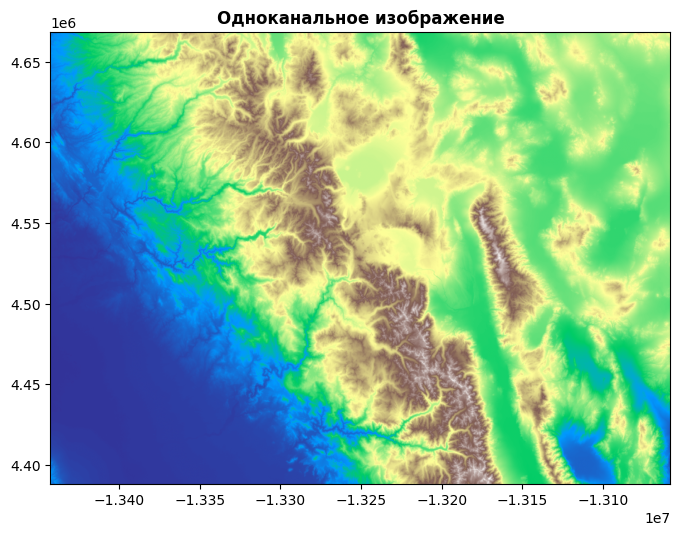

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))
rasterio.plot.show(src, cmap="terrain", ax=ax, title="Одноканальное изображение")
plt.show()

2. Откройте мультиспектральное изображение и визуализируйте первый канал с использованием подходящей цветовой карты.


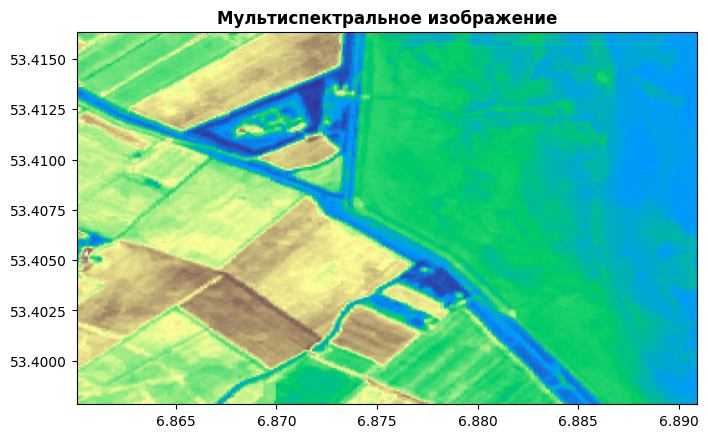

In [26]:
multi_imgpath = "https://github.com/opengeos/datasets/releases/download/raster/cog.tif"
multi_img = rasterio.open(multi_imgpath)

fig, ax = plt.subplots(figsize=(8, 8))
rasterio.plot.show((multi_img, 1), cmap="terrain", ax=ax, title="Мультиспектральное изображение")
plt.show()

3. Объедините несколько каналов из мультиспектрального изображения (например, Красный, Зеленый и Синий) и совместите их в один массив для создания RGB-композитного изображения.

>*Примечание:*
>
> При работе с многоканальными растровыми изображениями, особенно в формате COG.TIFF (Cloud Optimized GeoTIFF), может возникнуть проблема с некорректным отображением псевдоцветного изображения. Это связано с тем, что разные каналы могут иметь различные диапазоны значений пикселей.
>
> Для корректной визуализации на шаге 2 необходимо применить нормализацию к каждому каналу перед отображением.



Включите следующую функцию в ваш код:

```python
# Функция для нормализации канала в диапазон от 0 до 1
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm
```

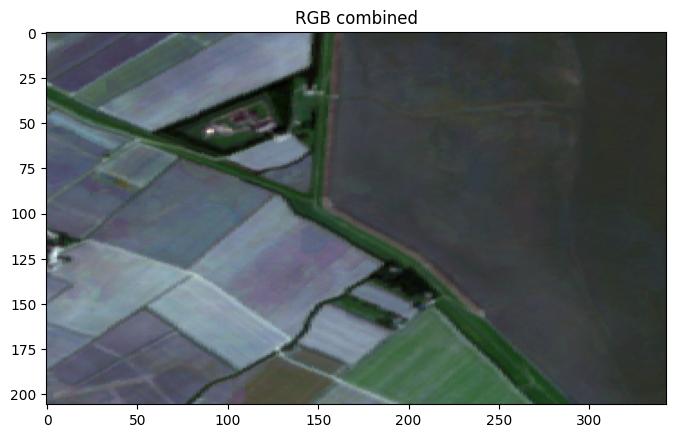

In [41]:
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm

red_band = normalize(multi_img.read(3))
green_band = normalize(multi_img.read(2))
blue_band = normalize(multi_img.read(1))

rgb = np.dstack((red_band, green_band, blue_band)).clip(0, 1)


plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("RGB combined")
plt.show()



### **Задание 3. Обрезка растра с использованием индексации массива**



1. Откройте мультиспектральное изображение и обрежьте его с использованием спискового среза (указав диапазоны строк и столбцов).


In [66]:
multi_img.shape

(206, 343)

In [69]:
h, w = multi_img.shape
data = multi_img.read()
subset = data[:, 50:150, 50:200]
subset.shape

(4, 100, 150)

2. Визуализируйте обрезанную часть изображения с использованием matplotlib, чтобы убедиться в корректном результате.


>*Примечание:*
>
> При работе с многоканальными растровыми изображениями, особенно в формате COG.TIFF (Cloud Optimized GeoTIFF), может возникнуть проблема с некорректным отображением псевдоцветного изображения. Это связано с тем, что разные каналы могут иметь различные диапазоны значений пикселей.
>
> Для корректной визуализации на шаге 2 необходимо применить нормализацию к каждому каналу перед отображением.



Включите следующую функцию в ваш код:

```python
# Функция для нормализации канала в диапазон от 0 до 1
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm
```

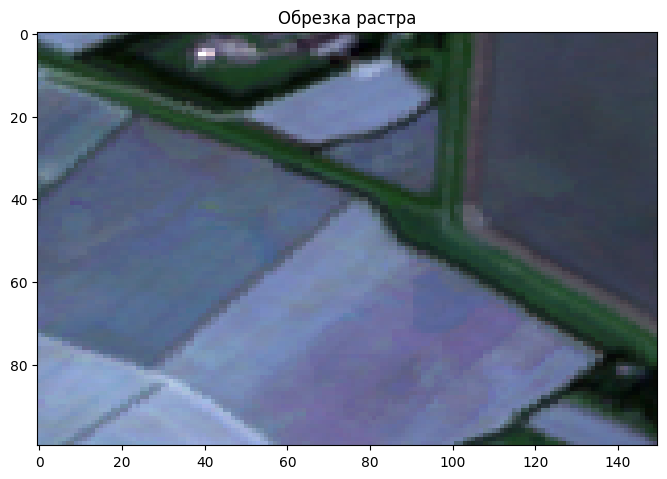

In [73]:
def normalize(band):
    band_min = band.min()
    band_max = band.max()
    band_norm = (band - band_min) / (band_max - band_min)
    return band_norm

rgb_subset = np.dstack((normalize(subset[2]), normalize(subset[1]), normalize(subset[0]))).clip(0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_subset)
plt.title("Обрезка растра")
plt.show()

3. Сохраните обрезанное подмножество растра в новый файл с именем `clipped_multispectral.tif`.

In [ ]:
# Ваш код

---



### **Задание 4. Вычисление NDWI (калькуляция каналов)**



1. Откройте мультиспектральное изображение и извлеките каналы Green (Зеленый) и Ближний инфракрасный (NIR).


In [74]:
nir_band = multi_img.read(4)
green_band = multi_img.read(2)

2. Вычислите Нормализованный разностный водный индекс ([NDWI](https://en.wikipedia.org/wiki/Normalized_difference_water_index)) по формуле:

    NDWI = (Green - NIR) / (Green + NIR)

In [76]:
ndwi = (green_band - nir_band) / (green_band + nir_band)
ndwi = ndwi.clip(-1, 1)

3. Визуализируйте результат NDWI с использованием цветовой карты, подходящей для воды (например, cmap='Blues'), чтобы выделить водные объекты.


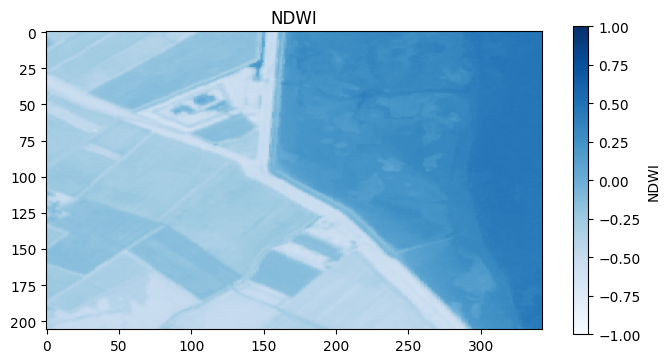

In [77]:
plt.figure(figsize=(8, 8))
plt.imshow(ndwi, cmap="Blues", vmin=-1, vmax=1)
plt.colorbar(label="NDWI", shrink=0.5)
plt.title("NDWI")
plt.show()



4. Сохраните полученное изображение NDWI как новый растровый файл с именем ndwi.tif.

In [ ]:
# Ваш код

---



### **Задание 5. Перепроецирование растровых данных**



1. Перепроецируйте одноканальный растр ЦМР из его исходной СК в EPSG:4326 (WGS 84) с использованием функции `rasterio.warp.reproject`.


In [ ]:
# Ваш код

2. Сохраните перепроецированный растр в новый файл GeoTIFF с именем `reprojected_dem.tif`.


In [ ]:
# Ваш код

3. Визуализируйте как исходный, так и перепроецированный наборы данных ЦМР, чтобы сравнить, как перепроецирование влияет на пространственное покрытие и разрешение.

In [ ]:
# Ваш код

---